In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
import numpy as np

# 1. Charger les données
df = pd.read_csv('Simulated_dataset.csv')

# 2. Convertir le Timestamp en objet datetime
df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])

# 3. Trier par date (au cas où)
df = df.sort_values('TimeStamp')

df = df.loc[df['Coordinates'] == '[0, 1]']

# 4. Gérer les données manquantes (NaN)
# Pour le Deep Learning et la visualisation, l'interpolation linéaire
# est souvent la meilleure méthode pour les capteurs
df_clean = df.copy()
numeric_cols = ["Air_temp","Humidity","Light_intensity","CO2","IsProbed","N","P","K","soil_moisture","green_px","necrotic_spot","GLI"]
df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method='linear')

# Afficher les premières lignes
print("Aperçu des données :")
display(df_clean.head())

Aperçu des données :


,TimeStamp,Coordinates,Air_temp,Humidity,Light_intensity,CO2,IsProbed,N,P,K,soil_moisture,green_px,necrotic_spot,GLI,state
0,2026-01-01 00:00:41,"[0, 1]",25.816311,72.052285,0.000000,900.914557,1,199.9744,74.9967,199.9716,94.7839,502.0,0.0,0.022,FI
3,2026-01-01 00:15:00,"[0, 1]",25.821740,72.336343,1.076863,899.556023,0,199.9744,74.9967,199.9716,94.7839,502.0,0.0,0.022,FI
6,2026-01-01 00:30:00,"[0, 1]",25.634144,73.084611,0.000000,897.983130,0,199.9744,74.9967,199.9716,94.7839,502.0,0.0,0.022,FI
9,2026-01-01 00:45:00,"[0, 1]",25.512876,73.473317,0.410837,900.362766,0,199.9744,74.9967,199.9716,94.7839,502.0,0.0,0.022,FI
12,2026-01-01 01:00:00,"[0, 1]",25.507487,74.145822,0.082850,899.055005,0,199.9744,74.9967,199.9716,94.7839,502.0,0.0,0.022,FI


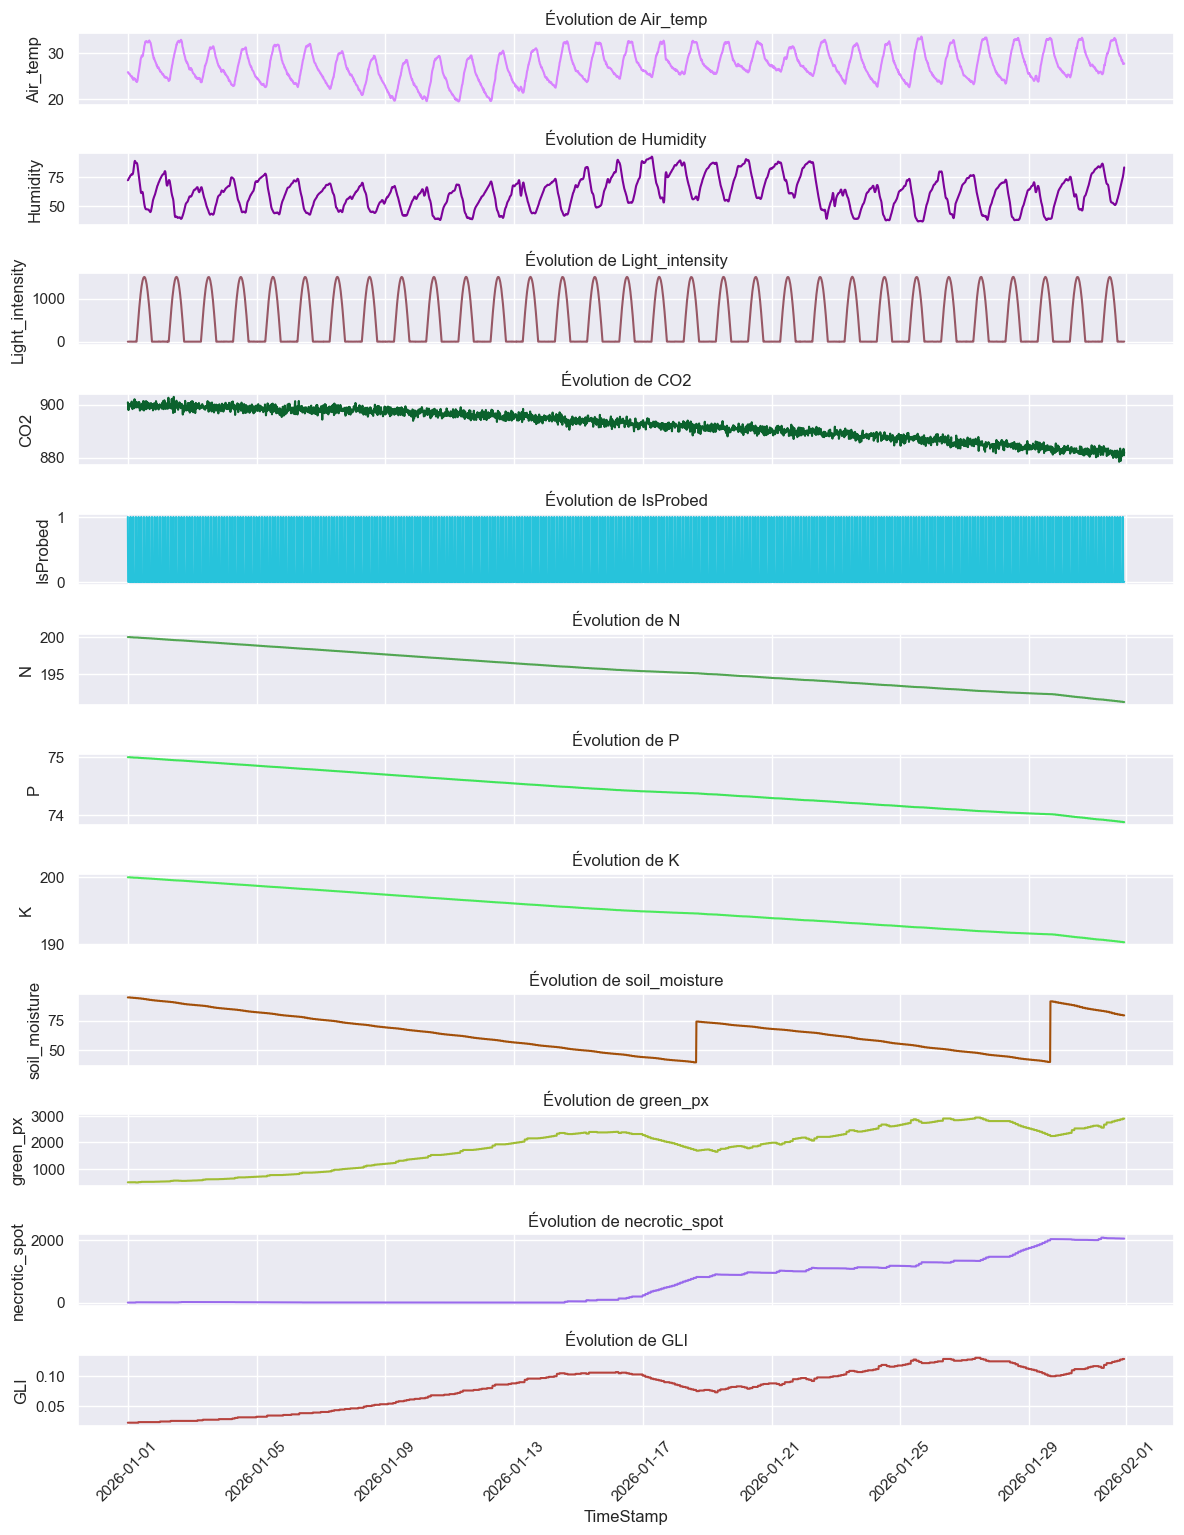

In [4]:
import random

# Configuration du style
sns.set(style="darkgrid")
fig, axes = plt.subplots(nrows=12, ncols=1, figsize=(12, 15), sharex=True)

variables = numeric_cols

for i, var in enumerate(variables):
    sns.lineplot(data=df_clean, x='TimeStamp', y=var, ax=axes[i], color="#{:06x}".format(random.randint(0, 0xFFFFFF)))
    axes[i].set_title(f'Évolution de {var}', fontsize=12)
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [21]:
# Transformation des données pour Plotly (format long)
df_melted = df_clean.melt(id_vars=['TimeStamp'], value_vars=variables,
                          var_name='Capteur', value_name='Valeur')

fig = px.line(df_melted, x='TimeStamp', y='Valeur', color='Capteur',
              title='Visualisation Interactive des Capteurs',
              labels={'TimeStamp': 'Temps', 'Valeur': 'Mesure'})

# Ajout de curseurs pour naviguer dans le temps
fig.update_xaxes(rangeslider_visible=True)

fig.show()